In [1]:
from IPython.display import HTML
HTML('''<style>
.jp-Cell-inputWrapper, .input { display: none; }
</style>
<script>
var codeVisible = false;
function toggleCode() {
    codeVisible = !codeVisible;
    var inputs = document.querySelectorAll('.jp-Cell-inputWrapper, .input');
    inputs.forEach(function(el) { el.style.display = codeVisible ? '' : 'none'; });
    document.getElementById('toggle-btn').textContent = codeVisible ? 'Hide Code' : 'Show Code';
}
</script>
<button id="toggle-btn" onclick="toggleCode()" style="position:fixed;top:10px;right:10px;z-index:9999;padding:8px 16px;background:#2a9d8f;color:white;border:none;border-radius:5px;cursor:pointer;font-size:13px;">Show Code</button>''')

# Disease Spread Prediction — Visualisation Report
## ENGG2112 — NSW SA2 Demographics, Flu Surveillance & Feature Analysis

**Team:** ENGG2112 Group  
**Date:** March 2026  
**Data source:** `data/processed/merged_sa2.csv` (produced by Notebook 01)

> **Note:** Run `01_data_exploration.ipynb` first to generate the processed dataset. All code is hidden by default — click "Show Code" (top-right) to reveal.

## Overview

This notebook presents publication-quality visualisations of the processed dataset produced by the data exploration pipeline. The charts cover NSW SA2 demographic distributions, flu surveillance time-series from the NNDSS (2008-2024), socioeconomic indicators, feature relationships relevant to outbreak prediction, and a preview of the grid-based SIR simulation. Each figure is accompanied by an interpretive commentary to support the final report.

## Table of Contents

1. [Data Loading](#1.-Data-Loading)
2. [Population & Geographic Distribution](#2.-Population-&-Geographic-Distribution)
3. [Age Demographics](#3.-Age-Demographics)
4. [Socioeconomic Landscape](#4.-Socioeconomic-Landscape)
5. [NNDSS Flu Surveillance](#5.-NNDSS-Flu-Surveillance)
6. [Flu Burden Analysis](#6.-Flu-Burden-Analysis)
7. [Feature Relationships](#7.-Feature-Relationships)
8. [Employment & Mobility](#8.-Employment-&-Mobility)
9. [Grid Simulation Preview](#9.-Grid-Simulation-Preview)
10. [Summary](#10.-Summary)

---
## 1. Data Loading

We load the merged SA2-level dataset (`merged_sa2.csv`) produced by Notebook 01. This file contains one row per NSW SA2 suburb with demographic features, derived flu burden estimates, and a binary outbreak label.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

RAW_DIR  = Path('../data/raw')
PROC_DIR = Path('../data/processed')
GCP_DIR  = RAW_DIR / 'abs_gcp_sa2_nsw' / '2021 Census GCP Statistical Area 2 for NSW'

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

df = pd.read_csv(PROC_DIR / 'merged_sa2.csv')
print(f'Loaded merged_sa2.csv - {len(df)} SA2 suburbs, {df.shape[1]} columns')
print(f'Outbreak rate: {df.outbreak.mean():.1%}  |  No outbreak: {(1-df.outbreak.mean()):.1%}')
df.head(3)

Loaded merged_sa2.csv - 641 SA2 suburbs, 15 columns
Outbreak rate: 25.1%  |  No outbreak: 74.9%


,sa2_code,sa2_name,area_sqkm,total_pop,pop_density,pct_0_14,pct_15_64,pct_65plus,median_age,median_hh_income_annual,commuter_rate,unemployment_rate,expected_flu_cases,flu_burden_per_1000,outbreak
0,101021007,Braidwood,3418.3525,4343,1.27,15.98,58.60,25.58,51.0,74308.0,0.5079,0.0354,32.44,7.4695,0
1,101021008,Karabar,6.9825,8517,1219.76,18.95,66.28,14.51,38.0,103428.0,0.5864,0.0467,64.01,7.5156,0
2,101021009,Queanbeyan,4.7620,11342,2381.77,15.31,68.67,16.09,37.0,88556.0,0.6153,0.0437,82.26,7.2527,0


The dataset has been loaded successfully. Each row represents a single NSW SA2 suburb with its associated demographic features, derived flu burden metric, and binary outbreak label. The outbreak rate printed above provides the class balance baseline that all subsequent visualisations reference.

---
## 2. Population & Geographic Distribution

Population size and density are fundamental drivers of infectious disease transmission. Denser suburbs facilitate higher contact rates between individuals, which in turn accelerates the spread of respiratory pathogens such as influenza. Understanding the distribution of population across NSW SA2s helps contextualise the outbreak risk landscape.

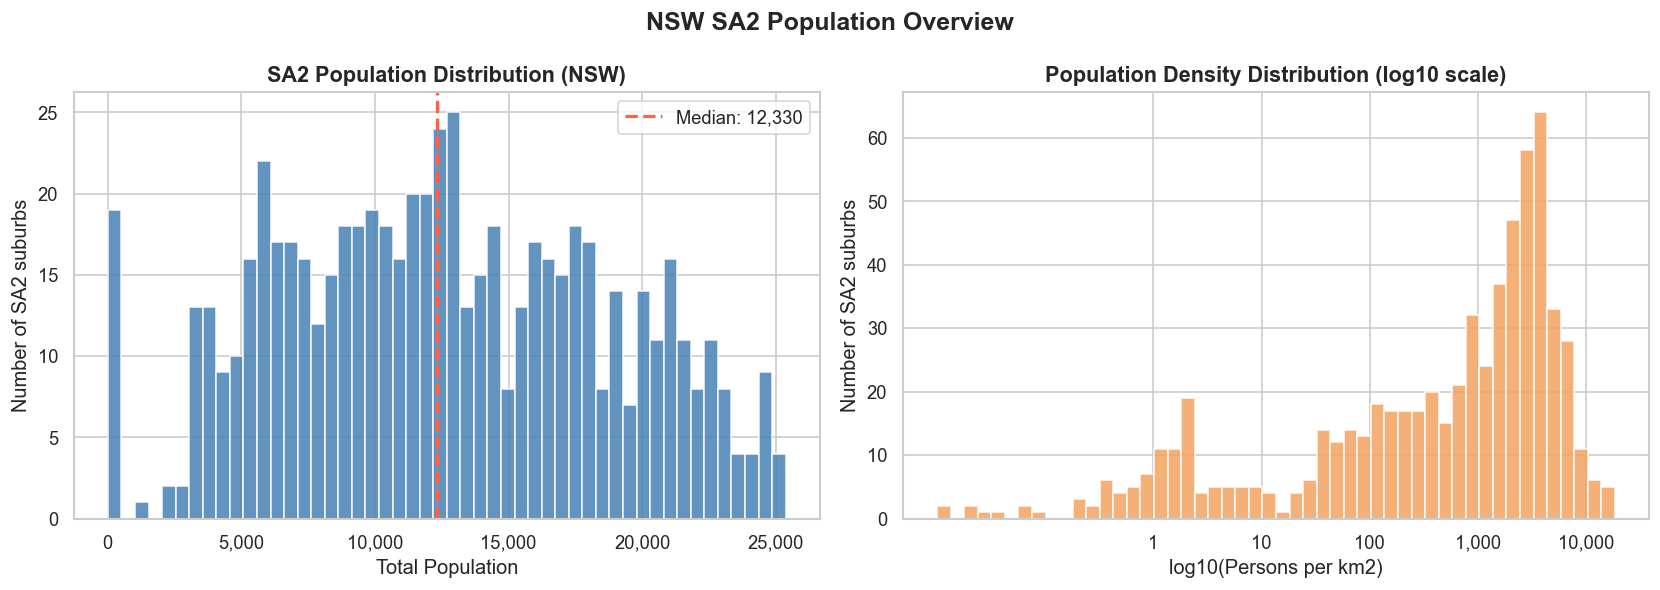

Most populous suburb: ['Lalor Park - Kings Langley' 25373]
Most dense suburb:    ['Sydney (South) - Haymarket' 18441.26]


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(df['total_pop'], bins=50, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(df['total_pop'].median(), color='tomato', linestyle='--', linewidth=2, label=f'Median: {df.total_pop.median():,.0f}')
ax.set_title('SA2 Population Distribution (NSW)')
ax.set_xlabel('Total Population')
ax.set_ylabel('Number of SA2 suburbs')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend()

ax = axes[1]
density_clean = df['pop_density'].replace([np.inf, -np.inf], np.nan).dropna()
density_nonzero = density_clean[density_clean > 0]
ax.hist(np.log10(density_nonzero), bins=50, color='#f4a261', edgecolor='white', alpha=0.85)
ax.set_title('Population Density Distribution (log10 scale)')
ax.set_xlabel('log10(Persons per km2)')
ax.set_ylabel('Number of SA2 suburbs')
tick_vals = [0, 1, 2, 3, 4]
ax.set_xticks(tick_vals)
ax.set_xticklabels([f'{10**v:,}' for v in tick_vals])

plt.suptitle('NSW SA2 Population Overview', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Most populous suburb: {df.nlargest(1, "total_pop")[["sa2_name","total_pop"]].values[0]}')
print(f'Most dense suburb:    {df.nlargest(1, "pop_density")[["sa2_name","pop_density"]].values[0]}')

Most NSW SA2 suburbs have populations in the 5,000-15,000 range, with a right-skewed tail representing large regional centres and high-density urban areas. Population density spans roughly four orders of magnitude on the log scale, from sparsely populated rural SA2s with fewer than 1 person per square kilometre to inner-city areas exceeding 10,000 persons per square kilometre. This enormous variation means that contact-rate-driven transmission dynamics will differ dramatically across the study region.

### Top 20 Most Populous Suburbs

The chart below highlights the 20 most populous SA2 suburbs in NSW, coloured by their outbreak label. This allows us to assess whether sheer population size alone is predictive of outbreak vulnerability.

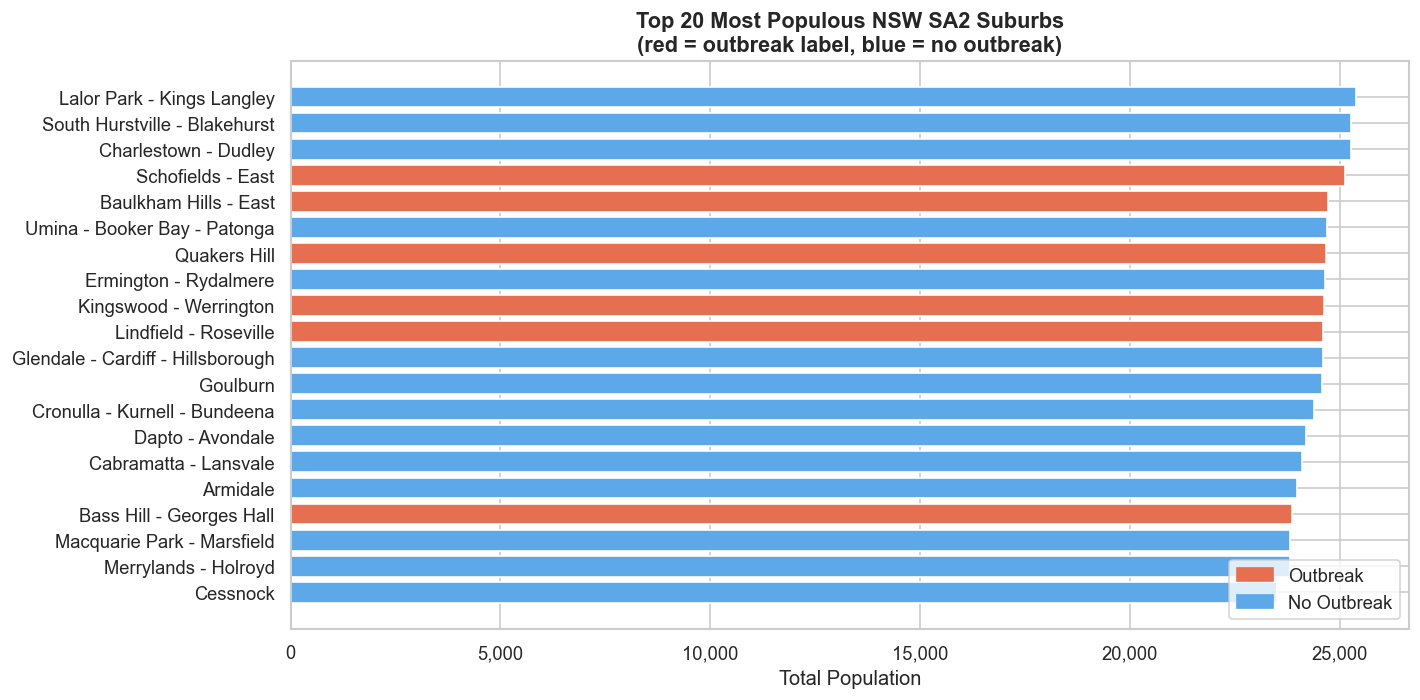

In [4]:
top20 = df.nlargest(20, 'total_pop')[['sa2_name', 'total_pop', 'pop_density', 'pct_65plus', 'outbreak']]
fig, ax = plt.subplots(figsize=(12, 6))
colours = ['#e76f51' if o == 1 else '#5ca8e8' for o in top20['outbreak']]
bars = ax.barh(top20['sa2_name'], top20['total_pop'], color=colours, edgecolor='white')
ax.set_xlabel('Total Population')
ax.set_title('Top 20 Most Populous NSW SA2 Suburbs\n(red = outbreak label, blue = no outbreak)')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.invert_yaxis()
legend_handles = [mpatches.Patch(color='#e76f51', label='Outbreak'),
                  mpatches.Patch(color='#5ca8e8', label='No Outbreak')]
ax.legend(handles=legend_handles, loc='lower right')
plt.tight_layout()
plt.show()

Among the most populous SA2 suburbs, only a subset carry the outbreak label. This confirms that population size alone is not a reliable predictor of flu outbreak vulnerability — demographic composition (particularly age structure) and socioeconomic factors play a more decisive role. Several large suburban growth corridors appear in this list without outbreak flags, while some moderately populated areas with older demographics are flagged.

---
## 3. Age Demographics

Age distribution is consistently the strongest driver of influenza burden at the population level. Crucially, **children (0–14) carry the highest age-specific flu notification rate in NSW (~14 per 1,000)**, nearly double the elderly rate (~7 per 1,000). Elderly residents (65+) face higher rates of severe outcomes (hospitalisation, mortality), but in terms of case counts driving the outbreak label, child-heavy suburbs dominate. Understanding the full age structure — not just the elderly share — is essential for accurate outbreak classification.

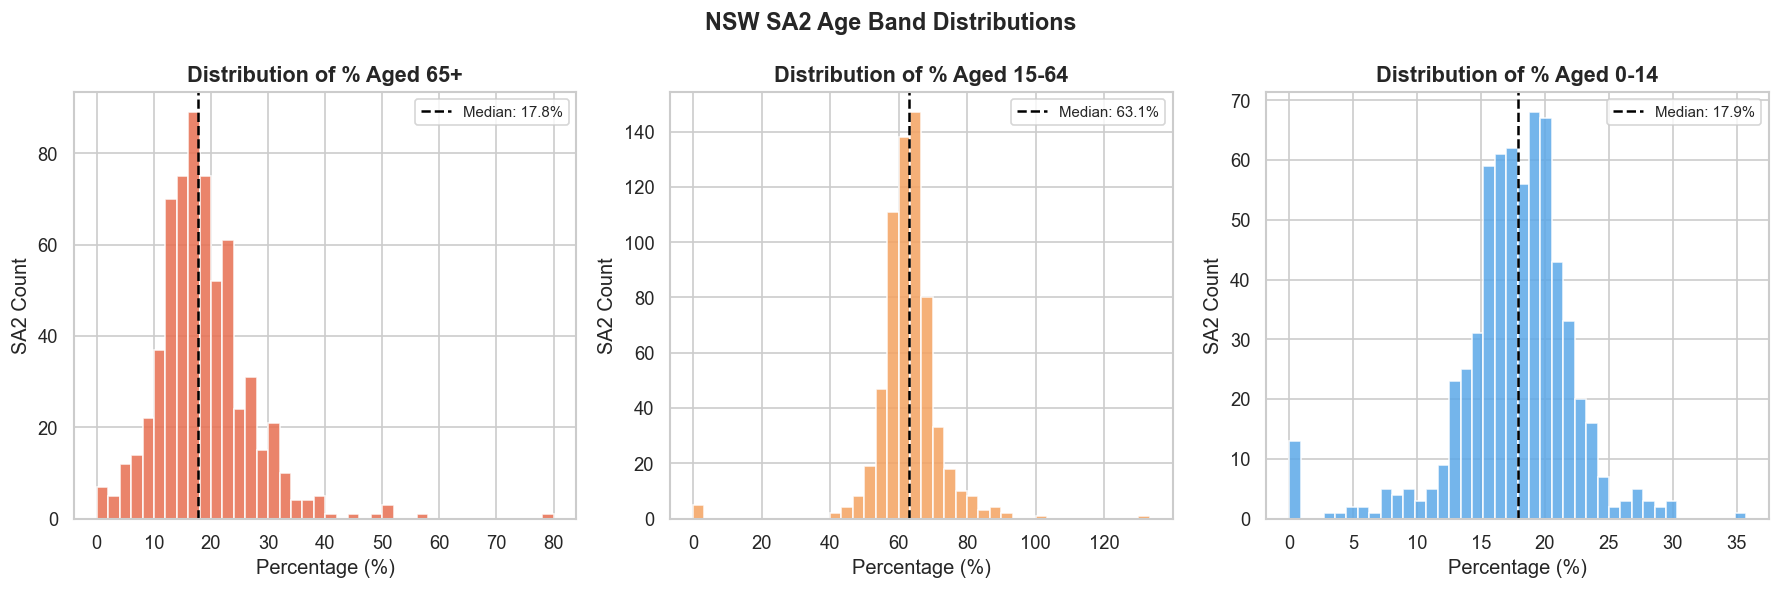

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
age_data = [
    ('pct_65plus', '% Aged 65+', '#e76f51'),
    ('pct_15_64', '% Aged 15-64', '#f4a261'),
    ('pct_0_14', '% Aged 0-14', '#5ca8e8'),
]
for ax, (col, label, colour) in zip(axes, age_data):
    data = df[col].dropna()
    ax.hist(data, bins=40, color=colour, edgecolor='white', alpha=0.85)
    ax.axvline(data.median(), color='black', linestyle='--', linewidth=1.5,
               label=f'Median: {data.median():.1f}%')
    ax.set_title(f'Distribution of {label}')
    ax.set_xlabel('Percentage (%)')
    ax.set_ylabel('SA2 Count')
    ax.legend(fontsize=9)
plt.suptitle('NSW SA2 Age Band Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

The elderly proportion (65+) shows a right-skewed distribution with a median around 16–18%, but notable outliers exceeding 30–40% corresponding to retirement communities and coastal retirement towns. The working-age band (15–64) is tightly concentrated around 65–70%, while the child population (0–14) clusters around 17–19% with a right-skewed tail of family-heavy growth corridors. Because children have the highest age-specific flu rate (~14 per 1,000), it is the **outlier suburbs at the high end of the pct_0_14 distribution** that carry the greatest expected flu burden — not simply the oldest suburbs.

### Oldest vs Youngest Suburbs

To make the age-driven risk more concrete, we compare the 15 SA2s with the highest elderly share against the 15 with the lowest. Median age annotations provide additional context.

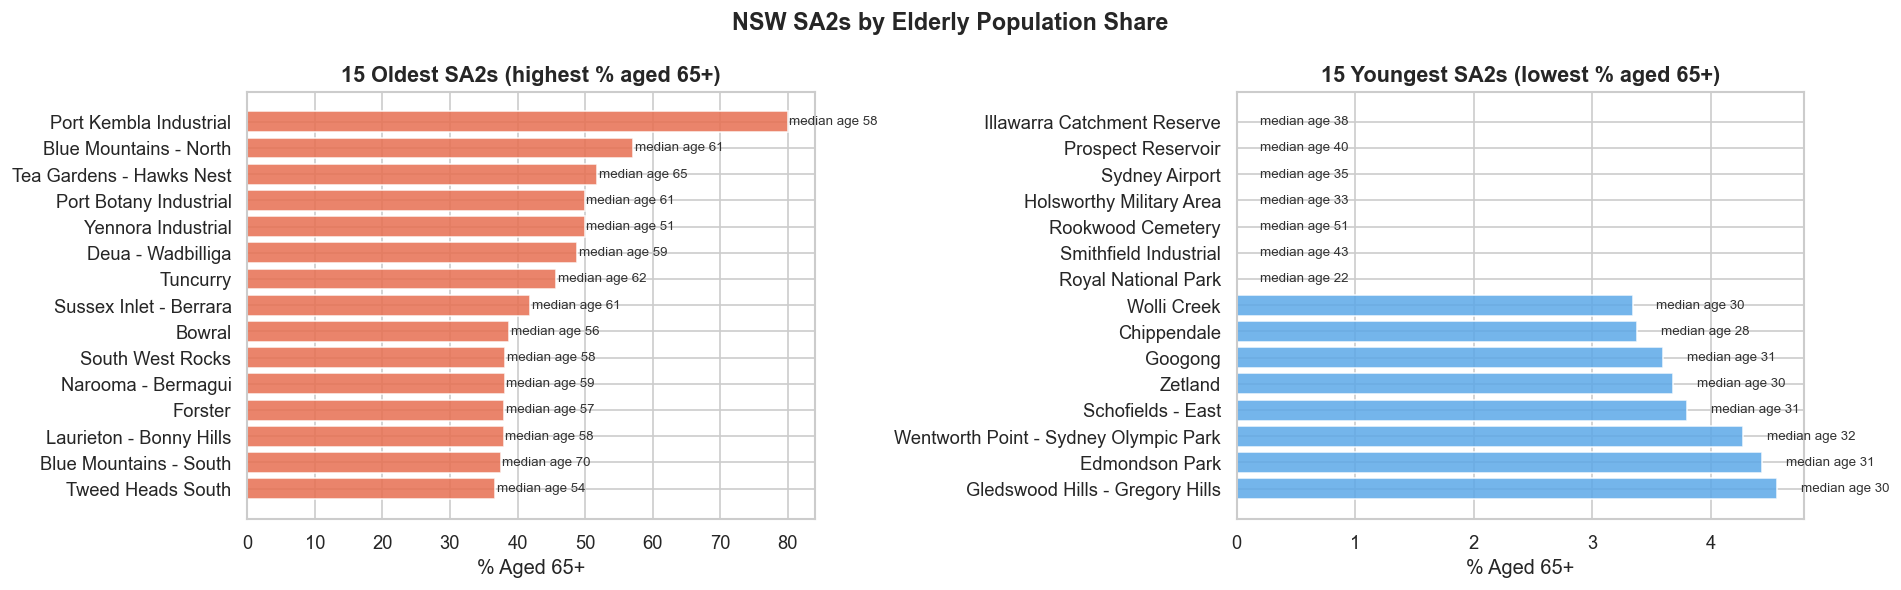

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
oldest = df.nlargest(15, 'pct_65plus')[['sa2_name', 'pct_65plus', 'median_age', 'flu_burden_per_1000']]
youngest = df.nsmallest(15, 'pct_65plus')[['sa2_name', 'pct_65plus', 'median_age', 'flu_burden_per_1000']]
for ax, data, title, colour in [
    (axes[0], oldest, '15 Oldest SA2s (highest % aged 65+)', '#e76f51'),
    (axes[1], youngest, '15 Youngest SA2s (lowest % aged 65+)', '#5ca8e8')
]:
    ax.barh(data['sa2_name'], data['pct_65plus'], color=colour, edgecolor='white', alpha=0.85)
    ax.set_xlabel('% Aged 65+')
    ax.set_title(title)
    ax.invert_yaxis()
    for j, (_, row) in enumerate(data.iterrows()):
        ax.text(row['pct_65plus'] + 0.2, j,
                f"median age {row['median_age']:.0f}", va='center', fontsize=8, color='#333')
plt.suptitle('NSW SA2s by Elderly Population Share', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

The oldest suburbs — typically coastal retirement towns and aged-care precincts — have elderly shares exceeding 30% and median ages well above 50. These areas carry elevated flu burden from the elderly contribution to the apportionment formula, but they are **not** the primary outbreak zones in the classification model; the top-burden tier is dominated by child-heavy family suburbs where pct_0_14 is high. In contrast, the youngest suburbs tend to be new housing developments and university-adjacent areas — some of which do have high child populations and thus elevated outbreak risk, while others with large young-adult (student) populations have lower burden.

---
## 4. Socioeconomic Landscape

Household income serves as a proxy for access to healthcare, vaccination uptake, and general health literacy. Lower-income suburbs may face compounding disadvantages — reduced access to preventive care, higher rates of chronic comorbidities, and more crowded living conditions — all of which elevate flu transmission and severity risk.

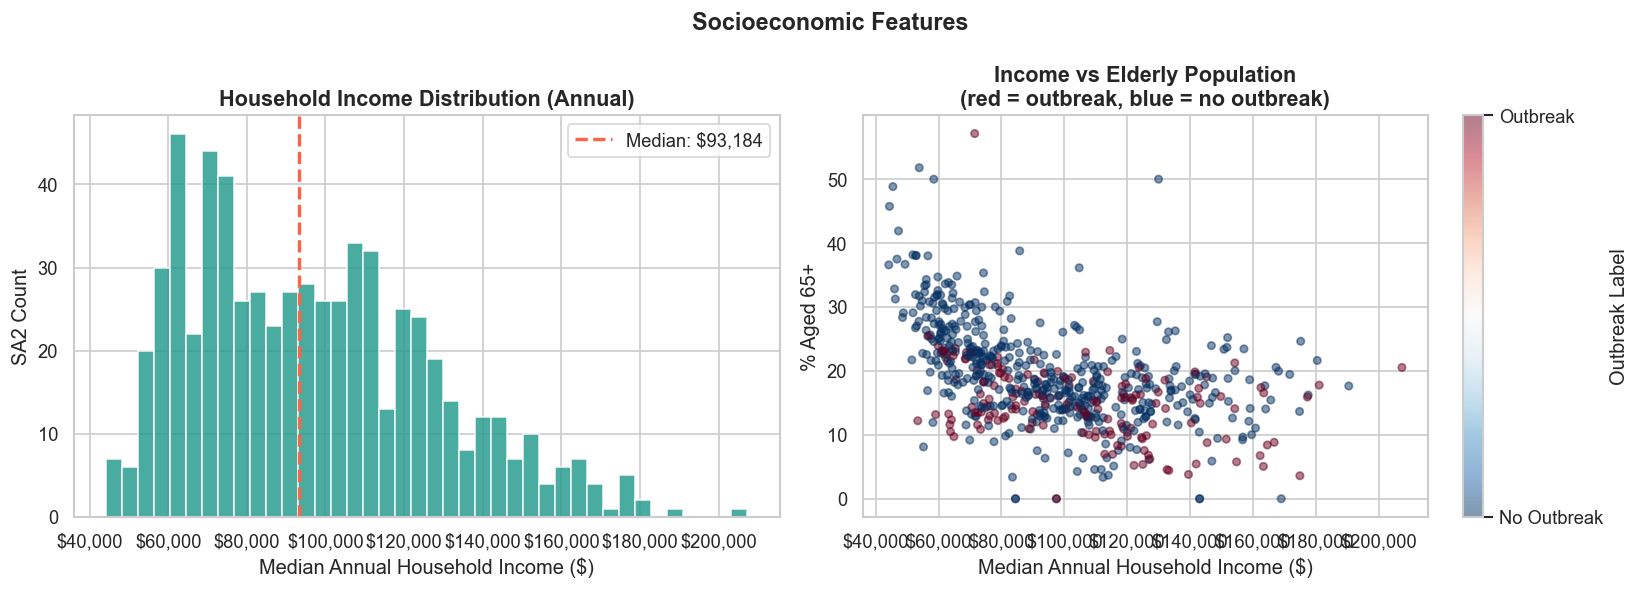

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
income_clean = df['median_hh_income_annual'].dropna()
ax.hist(income_clean, bins=40, color='#2a9d8f', edgecolor='white', alpha=0.85)
ax.axvline(income_clean.median(), color='tomato', linestyle='--', linewidth=2,
           label=f'Median: ${income_clean.median():,.0f}')
ax.set_title('Household Income Distribution (Annual)')
ax.set_xlabel('Median Annual Household Income ($)')
ax.set_ylabel('SA2 Count')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend()

ax = axes[1]
scatter = ax.scatter(df['median_hh_income_annual'], df['pct_65plus'],
    c=df['outbreak'], cmap='RdBu_r', alpha=0.5, s=20, vmin=0, vmax=1)
ax.set_xlabel('Median Annual Household Income ($)')
ax.set_ylabel('% Aged 65+')
ax.set_title('Income vs Elderly Population\n(red = outbreak, blue = no outbreak)')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Outbreak Label')
cbar.set_ticks([0, 1])
cbar.set_ticklabels(['No Outbreak', 'Outbreak'])
plt.suptitle('Socioeconomic Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

The household income distribution is roughly bell-shaped with a slight right skew, reflecting the mix of metropolitan, suburban, and regional economies across NSW. The scatter plot (income vs pct_65plus, coloured by outbreak) shows that outbreak suburbs are spread across income levels — many family-oriented outer-suburban growth areas with high child populations are in the middle-to-upper income range. Outbreak suburbs (red) tend to cluster at **lower pct_65plus values** (fewer elderly, more children), while non-outbreak suburbs at high pct_65plus values reflect retirement areas where elderly residents dominate. This reinforces that the child proportion — not income level — is the primary separator between classes.

### Income Extremes

Comparing the richest and poorest SA2 suburbs highlights the socioeconomic diversity across NSW and provides context for the income feature's role in the prediction pipeline.

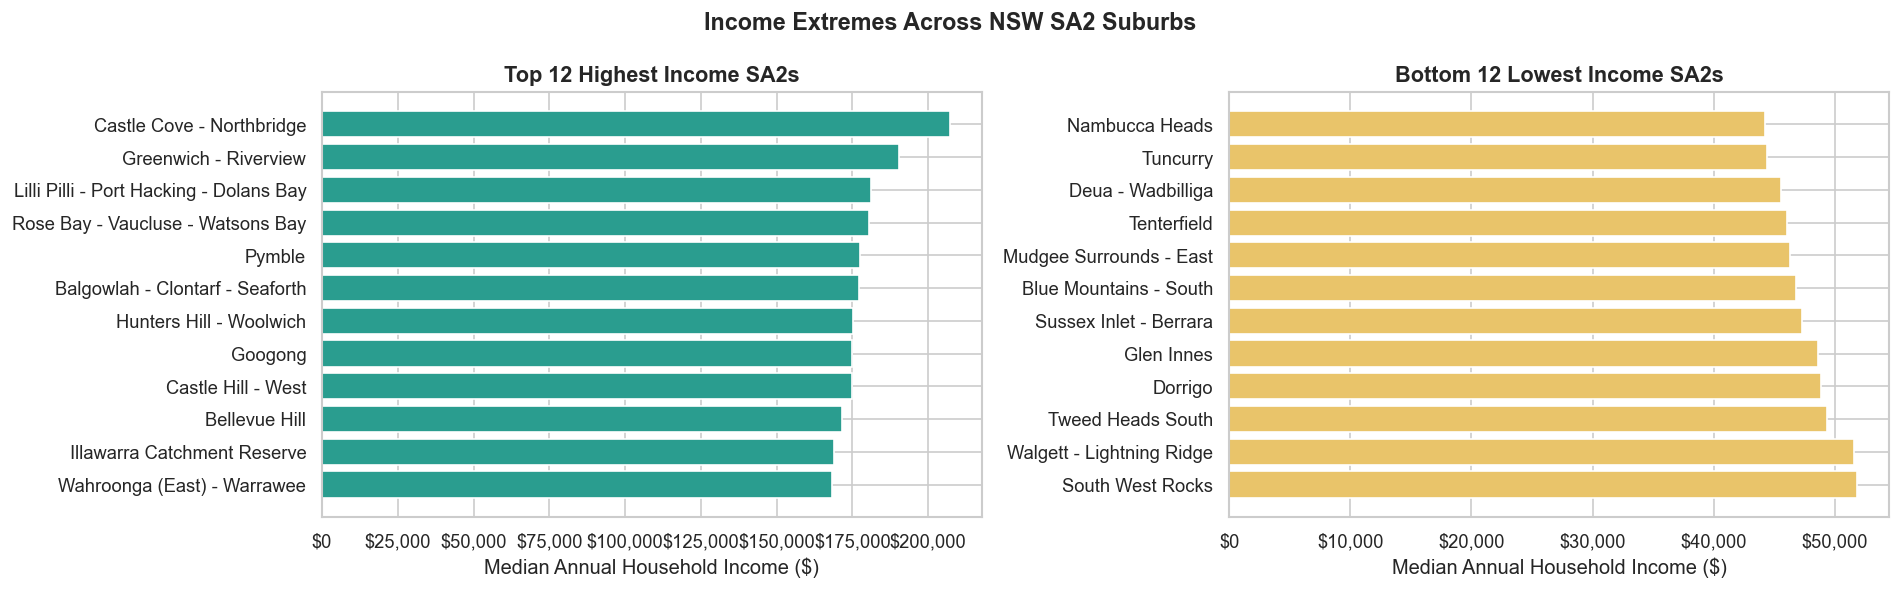

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
richest = df.nlargest(12, 'median_hh_income_annual')[['sa2_name', 'median_hh_income_annual']]
poorest = df.nsmallest(12, 'median_hh_income_annual')[['sa2_name', 'median_hh_income_annual']]
for ax, data, title, colour in [
    (axes[0], richest, 'Top 12 Highest Income SA2s', '#2a9d8f'),
    (axes[1], poorest, 'Bottom 12 Lowest Income SA2s', '#e9c46a')
]:
    ax.barh(data['sa2_name'], data['median_hh_income_annual'], color=colour, edgecolor='white')
    ax.set_xlabel('Median Annual Household Income ($)')
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    ax.set_title(title)
    ax.invert_yaxis()
plt.suptitle('Income Extremes Across NSW SA2 Suburbs', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

The highest-income SA2s are concentrated in Sydney's affluent North Shore and Eastern Suburbs, areas known for younger professional demographics and high healthcare access. The lowest-income SA2s include remote regional areas and suburbs with high proportions of retirees on fixed incomes. This income gradient aligns with the age-driven outbreak pattern — many low-income suburbs also have elevated elderly populations, reinforcing the compounding disadvantage hypothesis.

---
## 5. NNDSS Flu Surveillance

The National Notifiable Diseases Surveillance System (NNDSS) provides weekly counts of laboratory-confirmed influenza cases across Australian states and territories from 2008 to 2024. This section explores the raw surveillance data for NSW, examining temporal trends, seasonal patterns, age-group breakdowns, and influenza type/subtype distributions.

In [9]:
NNDSS_FILE = RAW_DIR / 'nndss_influenza_2008_2024.xlsx'
SHEETS = ['2008-2015', '2016-2018', '2019-2021', '2022-2024']
dfs = []
for sheet in SHEETS:
    df_s = pd.read_excel(NNDSS_FILE, sheet_name=sheet, header=1)
    dfs.append(df_s)
df_flu = pd.concat(dfs, ignore_index=True)
df_flu.columns = df_flu.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('/', '_')
df_flu = df_flu.rename(columns={'week_ending_(friday)': 'week_ending', 'age__group': 'age_group', 'type_subtype': 'flu_type'})
df_flu = df_flu[pd.to_datetime(df_flu['week_ending'], errors='coerce').notna()].copy()
df_flu['week_ending'] = pd.to_datetime(df_flu['week_ending'])
df_flu['year'] = df_flu['week_ending'].dt.year
df_flu['month'] = df_flu['week_ending'].dt.month
df_nsw = df_flu[df_flu['state'].str.upper() == 'NSW'].copy()
print(f'NNDSS loaded - {len(df_flu):,} total rows, {len(df_nsw):,} NSW rows')

NNDSS loaded - 1,974,685 total rows, 752,888 NSW rows


### 5.1 Weekly Case Timeline

The weekly case timeline provides the broadest view of influenza activity in NSW over the 16-year surveillance window. Key features to look for include the regular winter peaks, anomalous years, and the dramatic disruption caused by COVID-19 public health measures.

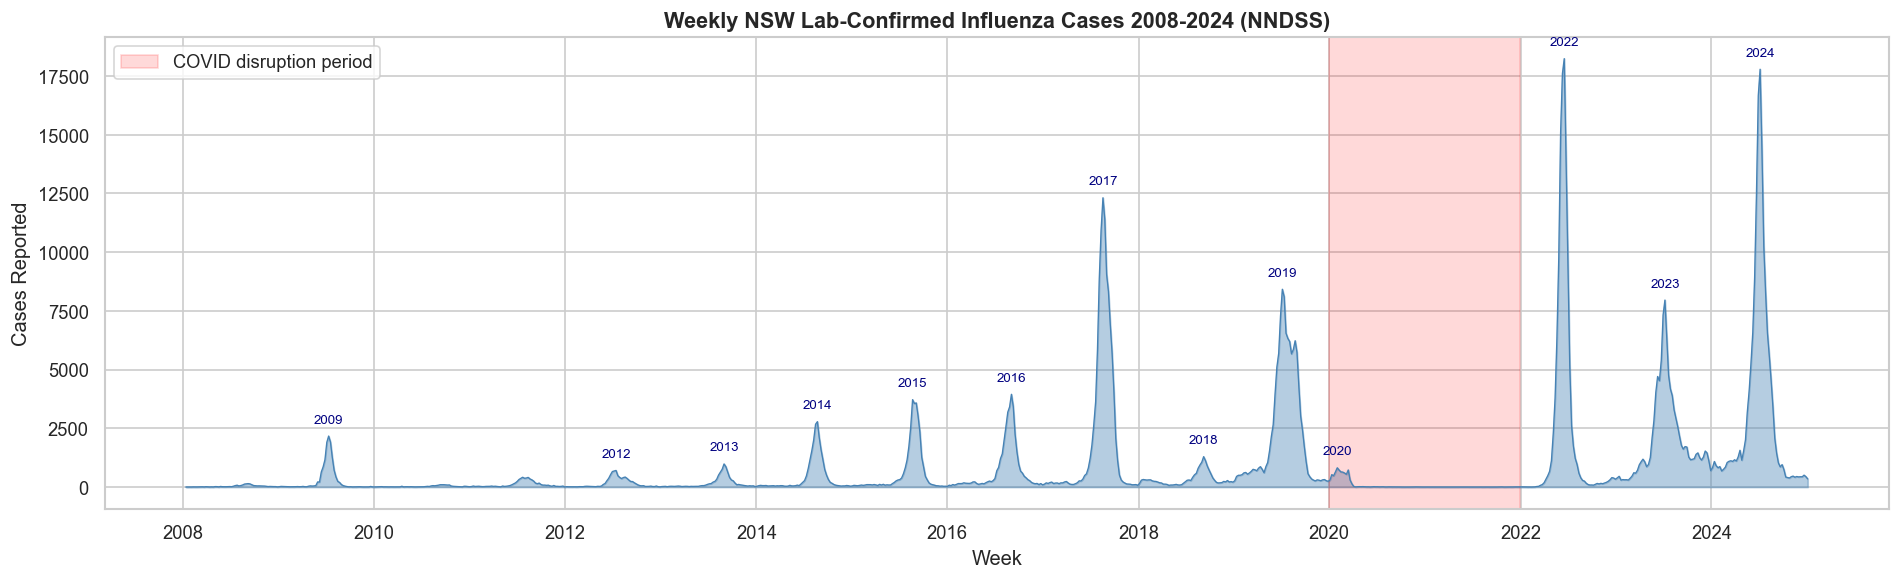

In [10]:
weekly_nsw = df_nsw.groupby('week_ending').size().reset_index(name='cases')
fig, ax = plt.subplots(figsize=(16, 5))
ax.fill_between(weekly_nsw['week_ending'], weekly_nsw['cases'], alpha=0.4, color='steelblue')
ax.plot(weekly_nsw['week_ending'], weekly_nsw['cases'], color='steelblue', linewidth=0.8)
ax.axvspan(pd.Timestamp('2020-01-01'), pd.Timestamp('2021-12-31'),
           alpha=0.15, color='red', label='COVID disruption period')
yearly_peak = weekly_nsw.loc[weekly_nsw.groupby(weekly_nsw['week_ending'].dt.year)['cases'].idxmax()]
for _, row in yearly_peak[yearly_peak['cases'] > 500].iterrows():
    ax.annotate(str(row['week_ending'].year),
                xy=(row['week_ending'], row['cases']),
                xytext=(0, 8), textcoords='offset points', ha='center', fontsize=8, color='navy')
ax.set_title('Weekly NSW Lab-Confirmed Influenza Cases 2008-2024 (NNDSS)', fontweight='bold')
ax.set_xlabel('Week')
ax.set_ylabel('Cases Reported')
ax.legend()
plt.tight_layout()
plt.show()

The timeline reveals a clear annual seasonality with peaks during the Australian winter (June-September). The 2017 and 2019 seasons stand out as particularly severe, with weekly case counts substantially exceeding other years. The COVID disruption period (2020-2021) is strikingly visible — influenza virtually disappeared as border closures, lockdowns, and social distancing measures suppressed respiratory virus transmission. The 2022 season marked a strong rebound, consistent with reduced population-level immunity following two years of minimal flu circulation.

### 5.2 Monthly Seasonality

To quantify the seasonal pattern, we average monthly case counts over the 2015-2019 pre-COVID baseline period. This removes year-to-year variation and isolates the underlying seasonal signal.

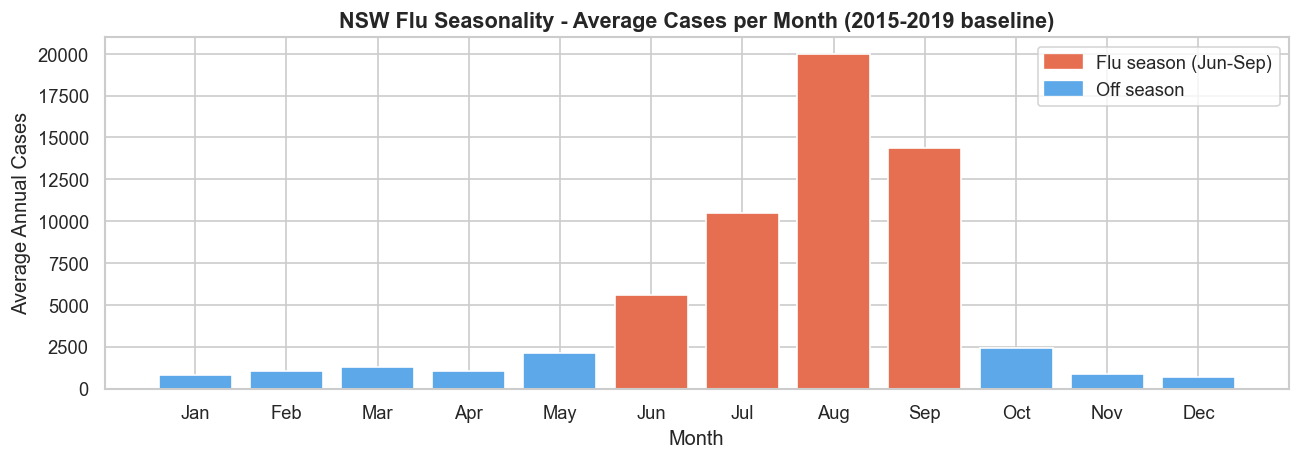

In [11]:
df_pre = df_nsw[df_nsw['year'].between(2015, 2019)]
monthly_avg = df_pre.groupby('month').size().reset_index(name='total')
monthly_avg['avg_per_year'] = (monthly_avg['total'] / 5).round(0)
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
fig, ax = plt.subplots(figsize=(11, 4))
colours_month = ['#e76f51' if m in [6,7,8,9] else '#5ca8e8' for m in monthly_avg['month']]
ax.bar(monthly_avg['month'], monthly_avg['avg_per_year'], color=colours_month, edgecolor='white')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names)
ax.set_title('NSW Flu Seasonality - Average Cases per Month (2015-2019 baseline)', fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Average Annual Cases')
flu_patch = mpatches.Patch(color='#e76f51', label='Flu season (Jun-Sep)')
off_patch = mpatches.Patch(color='#5ca8e8', label='Off season')
ax.legend(handles=[flu_patch, off_patch])
plt.tight_layout()
plt.show()

The seasonal pattern is unambiguous: influenza activity concentrates overwhelmingly in the June-September window, corresponding to the Australian winter. Activity ramps up in May, peaks around July-August, and tapers off through October. The off-season months (November-April) contribute minimal case counts. This seasonality is driven by lower temperatures and humidity that favour airborne virus survival, combined with increased indoor crowding during winter.

### 5.3 Age Group Breakdown by Year

Different age groups contribute differently to total case counts and to severe outcomes. This stacked bar chart decomposes annual case volumes by broad age band (children 0-14, working age 15-64, and elderly 65+) to reveal shifts in the burden over time.

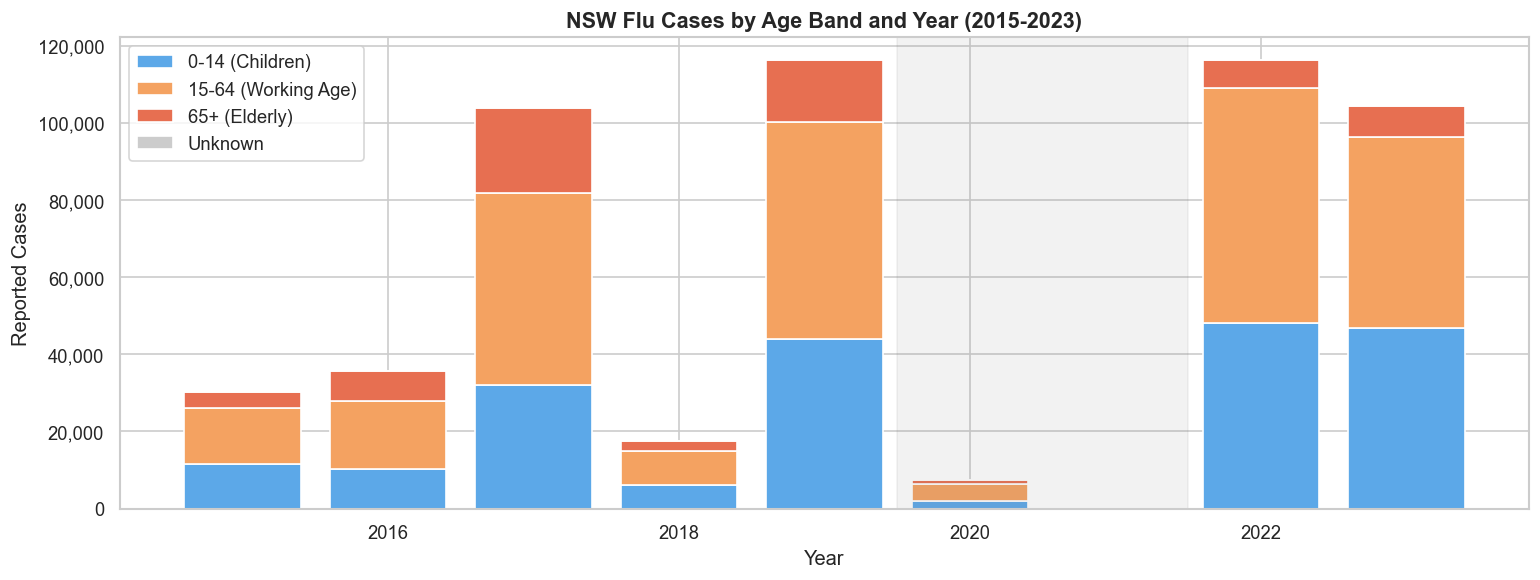

In [12]:
def map_age_band(ag):
    if pd.isna(ag): return 'Unknown'
    try:
        lower = int(str(ag).split('-')[0].split('+')[0].strip())
    except: return 'Unknown'
    if lower < 15: return '0-14 (Children)'
    if lower < 65: return '15-64 (Working Age)'
    return '65+ (Elderly)'

df_nsw['age_band'] = df_nsw['age_group'].apply(map_age_band)
age_year = df_nsw[df_nsw['year'].between(2015, 2023)].groupby(['year', 'age_band']).size().reset_index(name='cases')
age_pivot = age_year.pivot(index='year', columns='age_band', values='cases').fillna(0)

fig, ax = plt.subplots(figsize=(13, 5))
band_colours = {'0-14 (Children)': '#5ca8e8', '15-64 (Working Age)': '#f4a261',
                '65+ (Elderly)': '#e76f51', 'Unknown': '#ccc'}
bottom = np.zeros(len(age_pivot))
for band in ['0-14 (Children)', '15-64 (Working Age)', '65+ (Elderly)', 'Unknown']:
    if band in age_pivot.columns:
        vals = age_pivot[band].values
        ax.bar(age_pivot.index, vals, bottom=bottom,
               label=band, color=band_colours.get(band, '#aaa'), edgecolor='white')
        bottom += vals
ax.set_title('NSW Flu Cases by Age Band and Year (2015-2023)', fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Reported Cases')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend(loc='upper left')
ax.axvspan(2019.5, 2021.5, alpha=0.1, color='grey', label='COVID disruption')
plt.tight_layout()
plt.show()

By absolute count, the working-age group (15-64) contributes the largest share of notified cases in most years, reflecting its dominance in the population. However, when considered on a per-capita basis, the elderly (65+) bear a disproportionate burden — their notification rate per 100,000 population consistently exceeds that of younger groups. The COVID disruption years (2020-2021) show near-complete suppression across all age bands, with a sharp rebound in 2022 that affected all groups simultaneously.

### 5.4 Flu Type/Subtype Distribution

Influenza circulates as multiple types and subtypes (A/H1N1, A/H3N2, B/Victoria, B/Yamagata, etc.), each with different transmission characteristics and clinical severity. The distribution of circulating subtypes varies from season to season and influences overall disease burden.

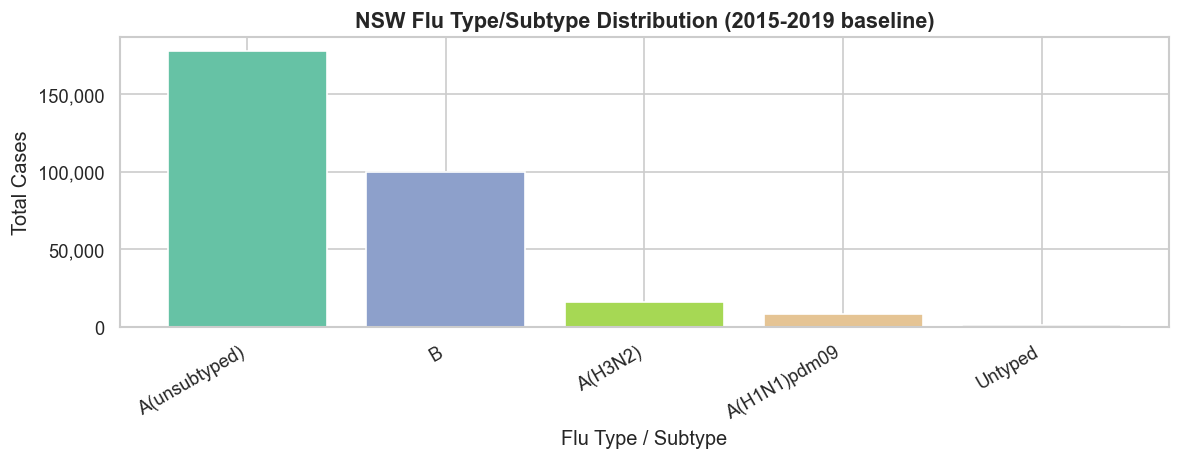

In [13]:
type_counts = df_pre.groupby('flu_type').size().reset_index(name='cases')
type_counts = type_counts.nlargest(8, 'cases')
fig, ax = plt.subplots(figsize=(10, 4))
colours_type = plt.cm.Set2(np.linspace(0, 1, len(type_counts)))
ax.bar(type_counts['flu_type'], type_counts['cases'], color=colours_type, edgecolor='white')
ax.set_title('NSW Flu Type/Subtype Distribution (2015-2019 baseline)', fontweight='bold')
ax.set_xlabel('Flu Type / Subtype')
ax.set_ylabel('Total Cases')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

The dominant subtypes over the 2015-2019 baseline include Influenza A (H3N2 and H1N1pdm09) and Influenza B lineages. H3N2 tends to cause more severe seasons, particularly in elderly populations, while H1N1pdm09 disproportionately affects younger adults. The subtype mix in any given season significantly influences the age distribution of cases and the overall severity of the outbreak, which is why our model uses age-weighted burden metrics rather than raw case counts.

---
## 6. Flu Burden Analysis

The derived flu burden metric (`flu_burden_per_1000`) estimates the expected number of flu cases per 1,000 residents in each SA2 suburb, based on the suburb's age structure and state-level age-specific notification rates. This section examines the distribution of this metric and its relationship to the binary outbreak label.

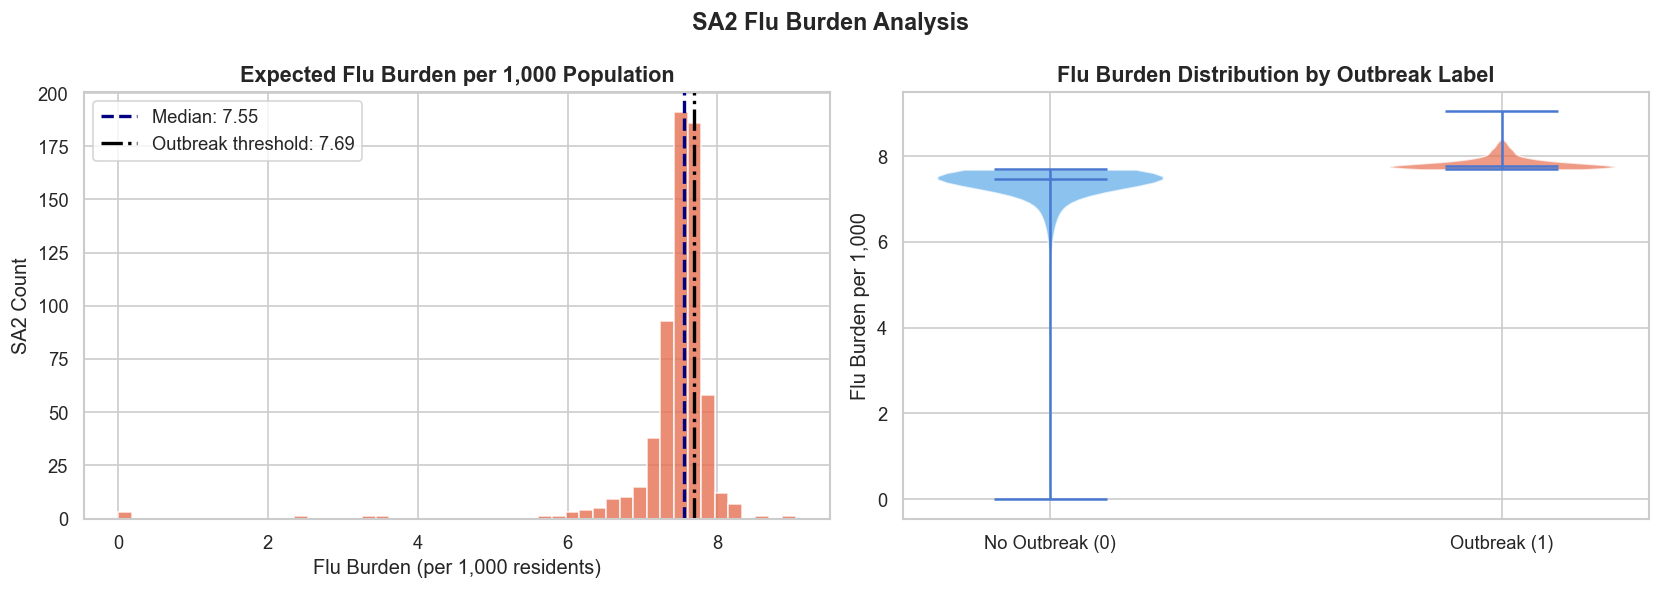

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
ax.hist(df['flu_burden_per_1000'], bins=50, color='#e76f51', edgecolor='white', alpha=0.8)
threshold_val = df[df['outbreak']==1]['flu_burden_per_1000'].min()
ax.axvline(df['flu_burden_per_1000'].median(), color='navy', linestyle='--',
           linewidth=2, label=f'Median: {df.flu_burden_per_1000.median():.2f}')
ax.axvline(threshold_val, color='black', linestyle='-.',
           linewidth=2, label=f'Outbreak threshold: {threshold_val:.2f}')
ax.set_title('Expected Flu Burden per 1,000 Population')
ax.set_xlabel('Flu Burden (per 1,000 residents)')
ax.set_ylabel('SA2 Count')
ax.legend()

ax = axes[1]
data_0 = df[df['outbreak']==0]['flu_burden_per_1000'].dropna()
data_1 = df[df['outbreak']==1]['flu_burden_per_1000'].dropna()
parts = ax.violinplot([data_0, data_1], positions=[0, 1], showmedians=True)
colours_v = ['#5ca8e8', '#e76f51']
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(colours_v[i])
    pc.set_alpha(0.7)
ax.set_xticks([0, 1])
ax.set_xticklabels(['No Outbreak (0)', 'Outbreak (1)'])
ax.set_ylabel('Flu Burden per 1,000')
ax.set_title('Flu Burden Distribution by Outbreak Label')
plt.suptitle('SA2 Flu Burden Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

The histogram shows a right-skewed distribution of flu burden with the outbreak threshold clearly separating the upper tail from the bulk of the distribution. The violin plot provides compelling visual evidence of class separation: outbreak-labelled suburbs have systematically higher flu burden values with minimal overlap in the distributions. This clean separation confirms that the derived burden metric is a strong discriminative feature for the classification task.

### Top 20 Highest Burden Suburbs

The following chart identifies the 20 SA2 suburbs with the highest expected flu burden per 1,000 residents, with bar colour encoding the proportion of elderly residents to highlight the age-burden relationship.

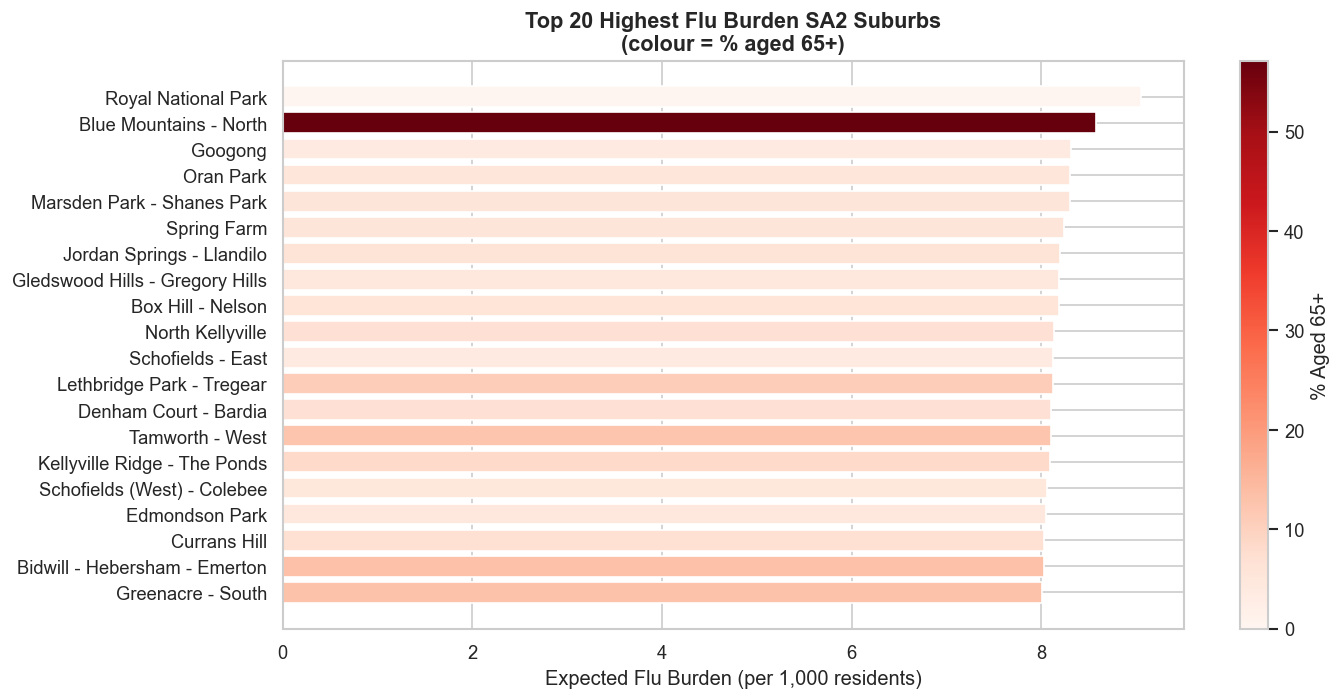

                       sa2_name  flu_burden_per_1000  pct_65plus  median_age
            Royal National Park               9.0476        0.00        22.0
         Blue Mountains - North               8.5714       57.14        61.0
                        Googong               8.3082        3.60        31.0
                      Oran Park               8.3069        5.22        30.0
     Marsden Park - Shanes Park               8.3058        5.44        32.0
                    Spring Farm               8.2399        5.37        30.0
      Jordan Springs - Llandilo               8.1924        6.24        31.0
Gledswood Hills - Gregory Hills               8.1908        4.56        30.0
              Box Hill - Nelson               8.1851        5.77        32.0
               North Kellyville               8.1334        6.75        33.0
              Schofields - East               8.1234        3.80        31.0
      Lethbridge Park - Tregear               8.1231       10.86        31.0

In [15]:
top_burden = df.nlargest(20, 'flu_burden_per_1000')[['sa2_name', 'flu_burden_per_1000', 'pct_65plus', 'median_age']]
fig, ax = plt.subplots(figsize=(12, 6))
cmap = plt.cm.Reds
norm = mcolors.Normalize(vmin=top_burden['pct_65plus'].min(), vmax=top_burden['pct_65plus'].max())
colours_b = [cmap(norm(v)) for v in top_burden['pct_65plus']]
ax.barh(top_burden['sa2_name'], top_burden['flu_burden_per_1000'], color=colours_b, edgecolor='white')
ax.set_xlabel('Expected Flu Burden (per 1,000 residents)')
ax.set_title('Top 20 Highest Flu Burden SA2 Suburbs\n(colour = % aged 65+)', fontweight='bold')
ax.invert_yaxis()
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label='% Aged 65+')
plt.tight_layout()
plt.show()
print(top_burden.to_string(index=False))

Note that the bars are coloured by **pct_65plus** (elderly share), but the highest-burden suburbs are primarily driven by high **pct_0_14** (child share) — since children have the highest age-specific notification rate (~14/1,000 vs ~7/1,000 for elderly). Many top-burden suburbs will therefore appear with moderate or even low colour intensity (lower elderly share), reflecting child-heavy demographics rather than retirement communities. Any bar with high colour intensity (high elderly share) still contributes meaningfully, but the child proportion is the dominant determinant of rank. These top-burden suburbs are the priority targets for vaccination campaigns, school-based interventions, and childcare facility outreach.

---
## 7. Feature Relationships

Before building predictive models, it is essential to understand pairwise relationships between features and the target variable. This section presents scatter-plot matrices, boxplot comparisons, and the full correlation heatmap — key diagnostic tools for identifying which features carry the most predictive signal and where multicollinearity may complicate model interpretation.

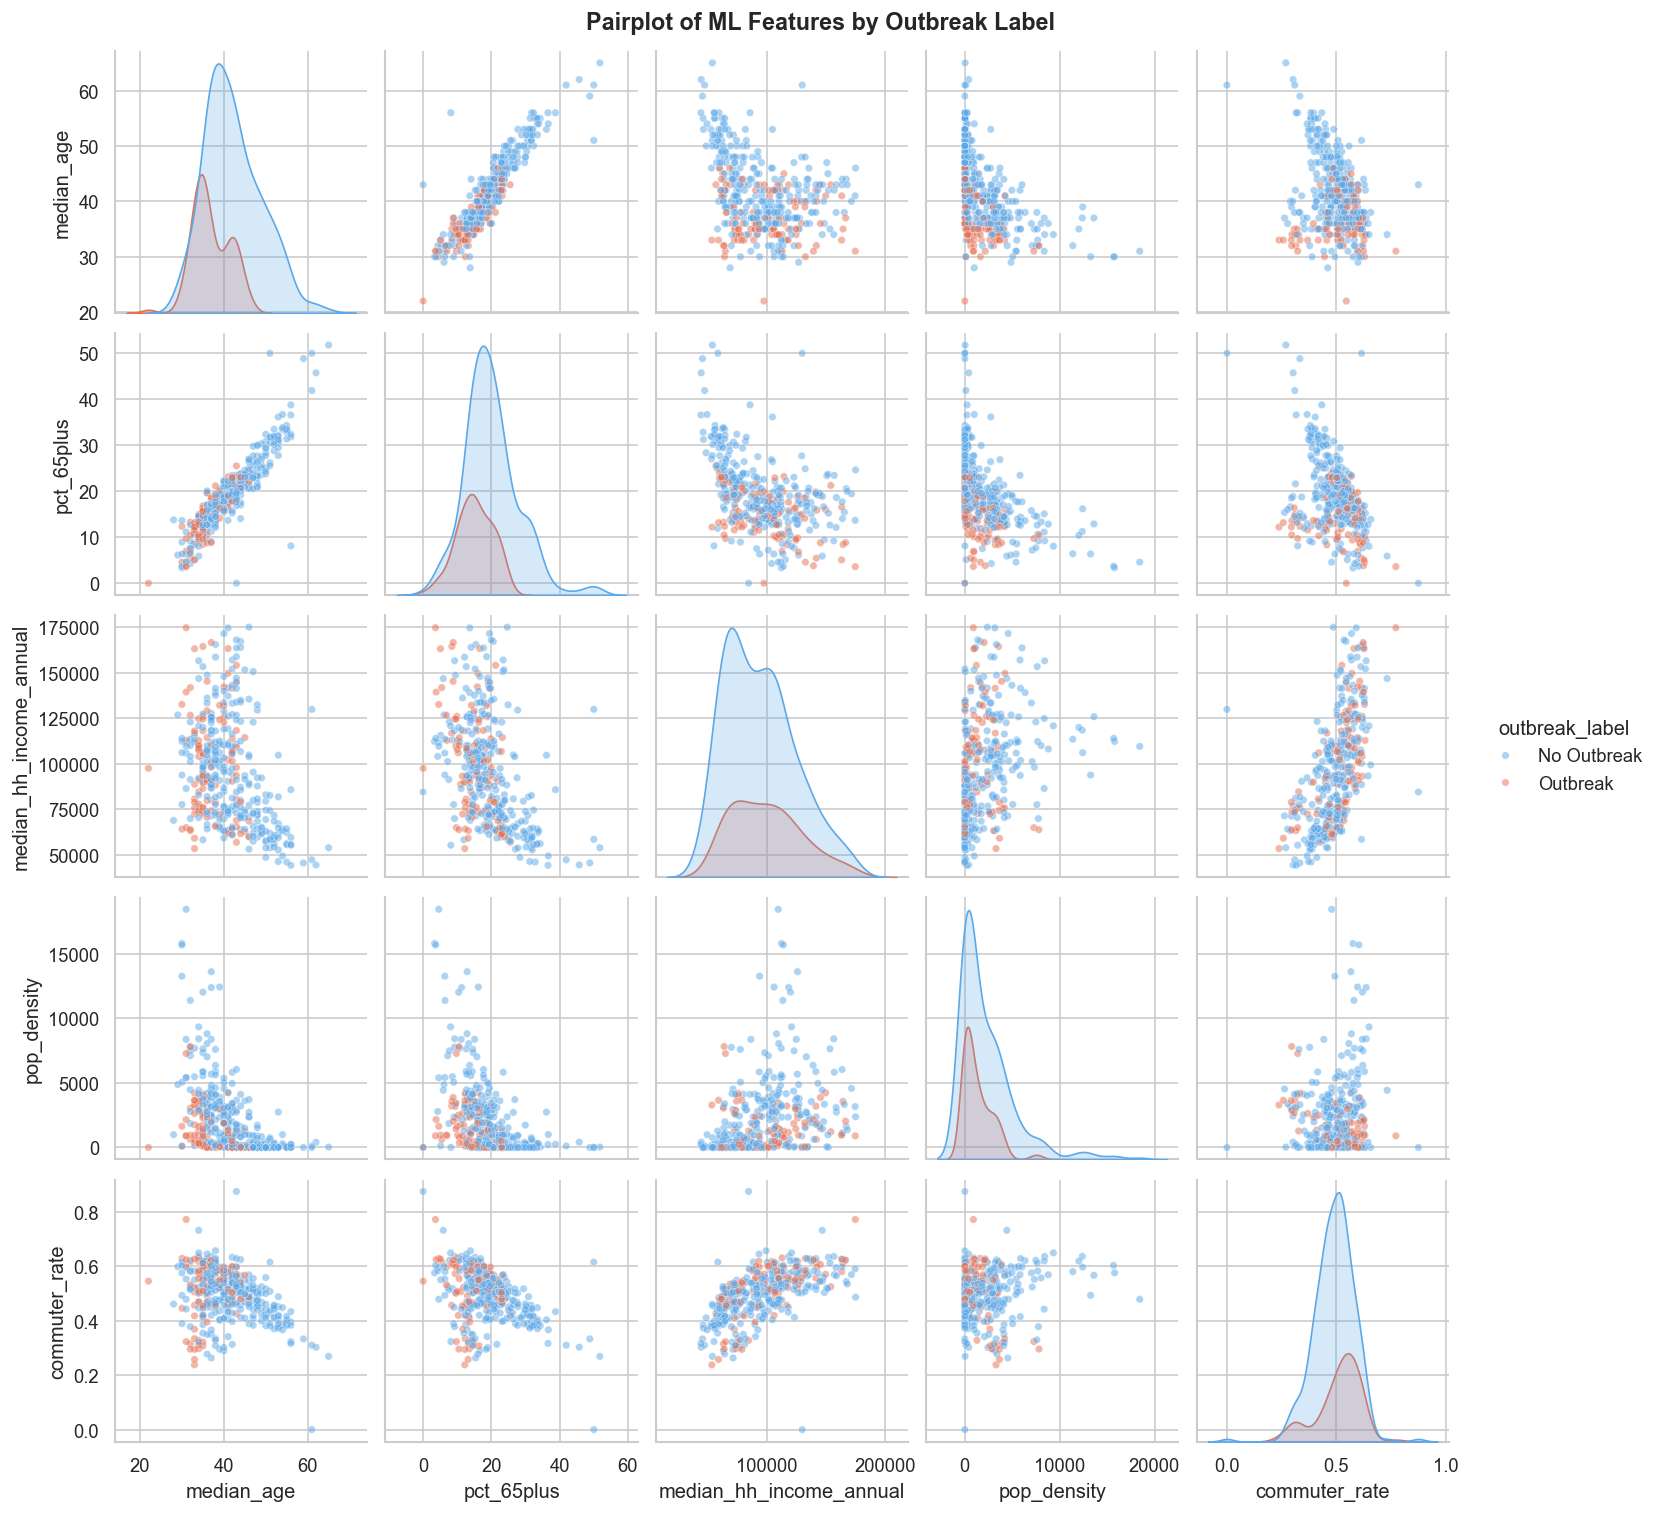

In [16]:
FEATURES = ['median_age', 'pct_65plus', 'median_hh_income_annual', 'pop_density', 'commuter_rate']
plot_df = df[FEATURES + ['outbreak']].dropna().sample(min(400, len(df)), random_state=42)
plot_df['outbreak_label'] = plot_df['outbreak'].map({0: 'No Outbreak', 1: 'Outbreak'})
g = sns.pairplot(plot_df, hue='outbreak_label', vars=FEATURES,
    palette={'No Outbreak': '#5ca8e8', 'Outbreak': '#e76f51'},
    plot_kws={'alpha': 0.5, 's': 20}, diag_kind='kde')
g.fig.suptitle('Pairplot of ML Features by Outbreak Label', y=1.01, fontsize=14, fontweight='bold')
plt.show()

The pairplot reveals several informative patterns. The median age and pct_65plus diagonal KDE plots show the clearest class separation, but with outbreak suburbs shifted **leftward toward younger demographics** — outbreak suburbs have lower median age and lower pct_65plus because they are child-heavy, not elderly-heavy. The median_age vs pct_65plus scatter confirms their strong positive correlation, and both features separate classes in the same (counter-intuitive) direction. Income shows a moderate negative association with age-related features, meaning wealthier suburbs tend to be younger. Population density and commuter rate show weaker but still visible class separation, suggesting they contribute complementary information to the prediction task.

### Boxplots: Outbreak vs Non-Outbreak

Boxplots provide a concise summary of the distributional differences between outbreak and non-outbreak suburbs for each feature. The median shift and degree of overlap between the two classes indicate each feature's discriminative power.

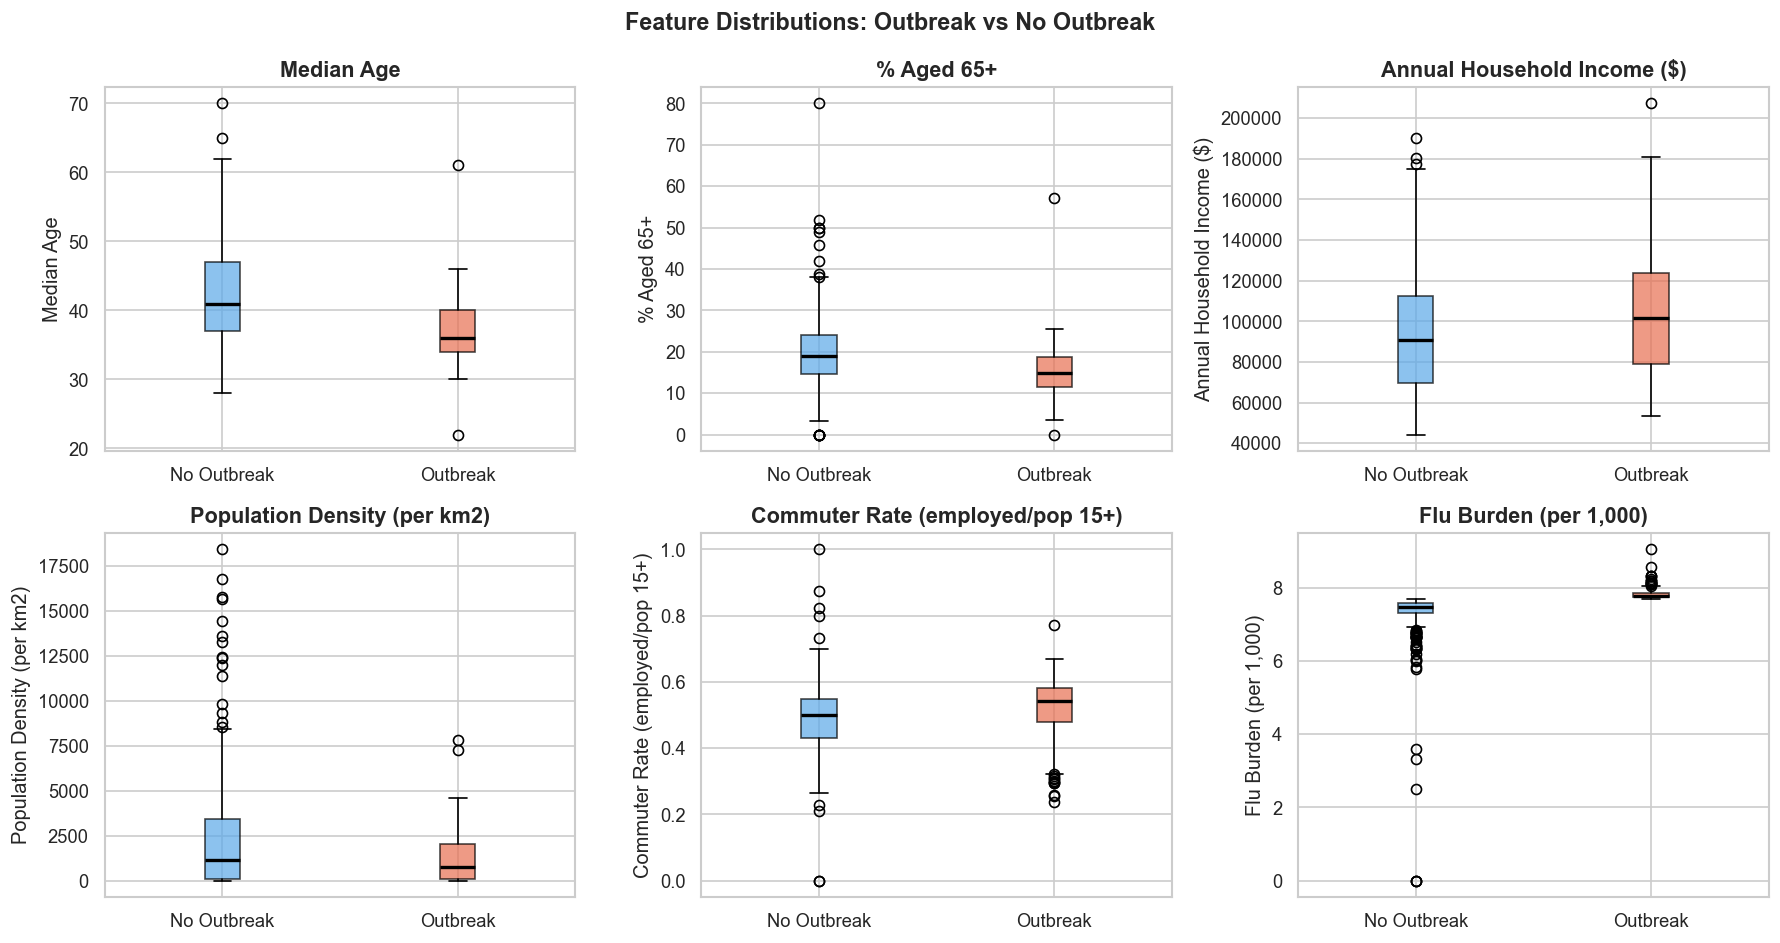

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
feat_labels = {
    'median_age': 'Median Age', 'pct_65plus': '% Aged 65+',
    'median_hh_income_annual': 'Annual Household Income ($)',
    'pop_density': 'Population Density (per km2)',
    'commuter_rate': 'Commuter Rate (employed/pop 15+)',
    'flu_burden_per_1000': 'Flu Burden (per 1,000)'
}
for i, (feat, label) in enumerate(feat_labels.items()):
    ax = axes[i]
    data_no = df[df['outbreak']==0][feat].dropna()
    data_yes = df[df['outbreak']==1][feat].dropna()
    bp = ax.boxplot([data_no, data_yes], patch_artist=True,
                    medianprops=dict(color='black', linewidth=2))
    bp['boxes'][0].set_facecolor('#5ca8e8')
    bp['boxes'][0].set_alpha(0.7)
    if len(bp['boxes']) > 1:
        bp['boxes'][1].set_facecolor('#e76f51')
        bp['boxes'][1].set_alpha(0.7)
    ax.set_xticklabels(['No Outbreak', 'Outbreak'])
    ax.set_title(label)
    ax.set_ylabel(label)
plt.suptitle('Feature Distributions: Outbreak vs No Outbreak', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

The boxplots confirm the feature hierarchy. Median age and pct_65plus show the largest median shifts between classes, but in the **downward** direction — outbreak suburbs have lower median age and lower pct_65plus, because the outbreak class is driven by child-heavy suburbs. Flu burden per 1,000 shows near-perfect separation (by construction). Household income shows a slight upward shift for outbreak suburbs (family-oriented areas tend to be middle-to-upper income), rather than a downward shift. Population density and commuter rate display smaller but visible differences, with outbreak suburbs tending toward lower values (outer suburban, lower commuting rates consistent with more children and fewer working-age adults).

### Full Correlation Heatmap

The correlation matrix quantifies linear associations between all numeric features and the outbreak target. High inter-feature correlations indicate multicollinearity that may require regularisation or feature selection during model training.

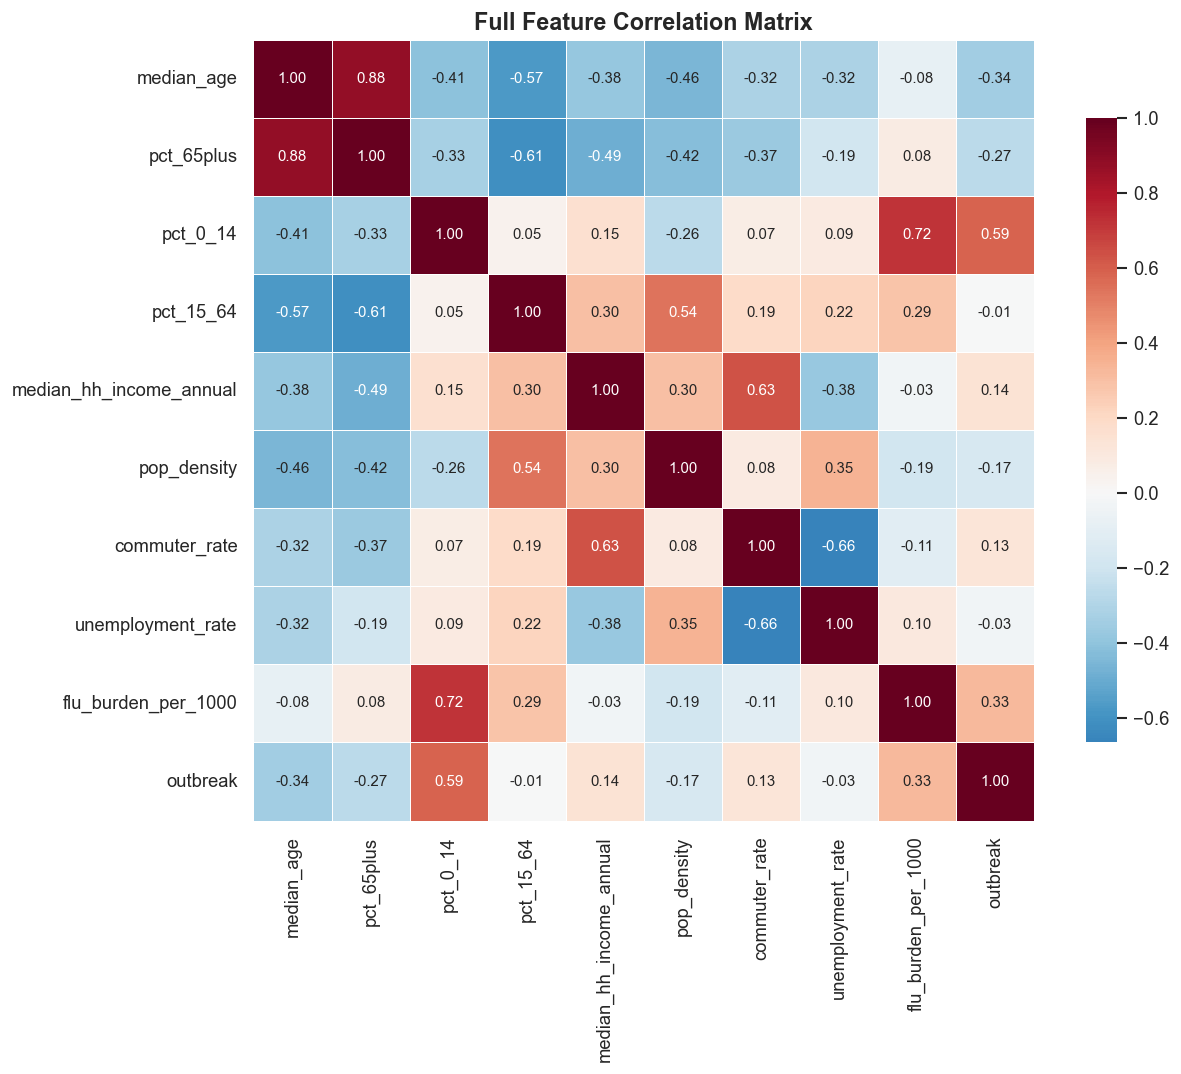


Correlation with outbreak label:
pct_0_14                   0.586
flu_burden_per_1000        0.328
median_hh_income_annual    0.142
commuter_rate              0.131
pct_15_64                 -0.005
unemployment_rate         -0.029
pop_density               -0.165
pct_65plus                -0.268
median_age                -0.341


In [18]:
ALL_FEATS = ['median_age', 'pct_65plus', 'pct_0_14', 'pct_15_64',
             'median_hh_income_annual', 'pop_density', 'commuter_rate',
             'unemployment_rate', 'flu_burden_per_1000', 'outbreak']
corr = df[ALL_FEATS].corr()
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, ax=ax, linewidths=0.5, cbar_kws={'shrink': 0.8}, annot_kws={'size': 9})
ax.set_title('Full Feature Correlation Matrix', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()
print('\nCorrelation with outbreak label:')
print(corr['outbreak'].drop('outbreak').sort_values(ascending=False).round(3).to_string())

The heatmap reveals several important patterns. **Flu burden per 1,000** has the highest positive correlation with outbreak, followed by **pct_0_14** (children) — the primary driver of the burden score. Counterintuitively, **pct_65plus and median_age show negative correlations** with outbreak: suburbs with more elderly tend to have fewer children, and since children drive the highest burden, elderly-heavy suburbs fall below the outbreak threshold. **pct_0_14 and pct_65plus are strongly negatively correlated** by construction (compositional constraint). Household income shows a weak positive correlation with outbreak (child-heavy family suburbs skew middle-income), and commuter rate is slightly negative. Notable multicollinearity exists between median_age and pct_65plus (near-perfect positive). These redundancies should be addressed through feature selection or regularisation before training the final ML model.

---
## 8. Employment & Mobility

The commuter rate (ratio of employed workers to total population aged 15+) serves as a proxy for daily mobility and inter-suburb mixing. Suburbs with higher commuter rates may act as conduits for disease spread across the metropolitan network, even if their resident demographics are not inherently high-risk.

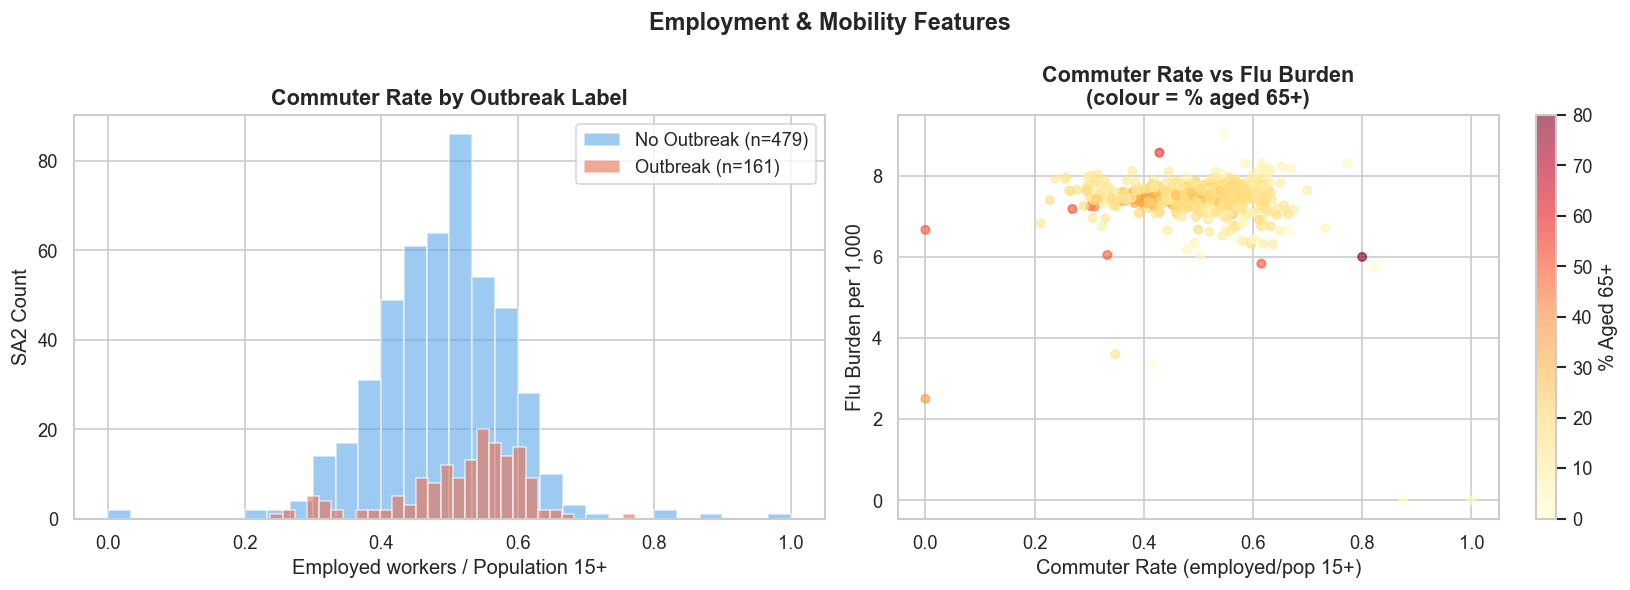

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
for outbreak_val, colour, name in [(0, '#5ca8e8', 'No Outbreak'), (1, '#e76f51', 'Outbreak')]:
    data = df[df['outbreak']==outbreak_val]['commuter_rate'].dropna()
    ax.hist(data, bins=30, alpha=0.6, color=colour, label=f'{name} (n={len(data)})', edgecolor='white')
ax.set_title('Commuter Rate by Outbreak Label')
ax.set_xlabel('Employed workers / Population 15+')
ax.set_ylabel('SA2 Count')
ax.legend()

ax = axes[1]
sc = ax.scatter(df['commuter_rate'], df['flu_burden_per_1000'],
                c=df['pct_65plus'], cmap='YlOrRd', alpha=0.6, s=25)
ax.set_xlabel('Commuter Rate (employed/pop 15+)')
ax.set_ylabel('Flu Burden per 1,000')
ax.set_title('Commuter Rate vs Flu Burden\n(colour = % aged 65+)')
plt.colorbar(sc, ax=ax, label='% Aged 65+')
plt.suptitle('Employment & Mobility Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

The overlapping histograms show that outbreak suburbs tend to have lower commuter rates than non-outbreak suburbs, consistent with their older, more retired populations. The scatter plot reinforces this: suburbs with high flu burden (top of the y-axis) tend to cluster at lower commuter rates and are coloured in deep red/orange (high elderly share). This inverse relationship between commuter rate and flu burden arises because retirement-heavy suburbs have fewer working-age residents commuting, yet face the highest per-capita disease risk due to their age structure.

---
## 9. Grid Simulation Preview

This section provides a preview of the 50x50 grid-based SIR (Susceptible-Infected-Recovered) simulation that will form the core of the disease spread modelling component. The grid cells are populated with flu burden values sampled from the real SA2 data to illustrate how demographic heterogeneity influences spatial disease dynamics.

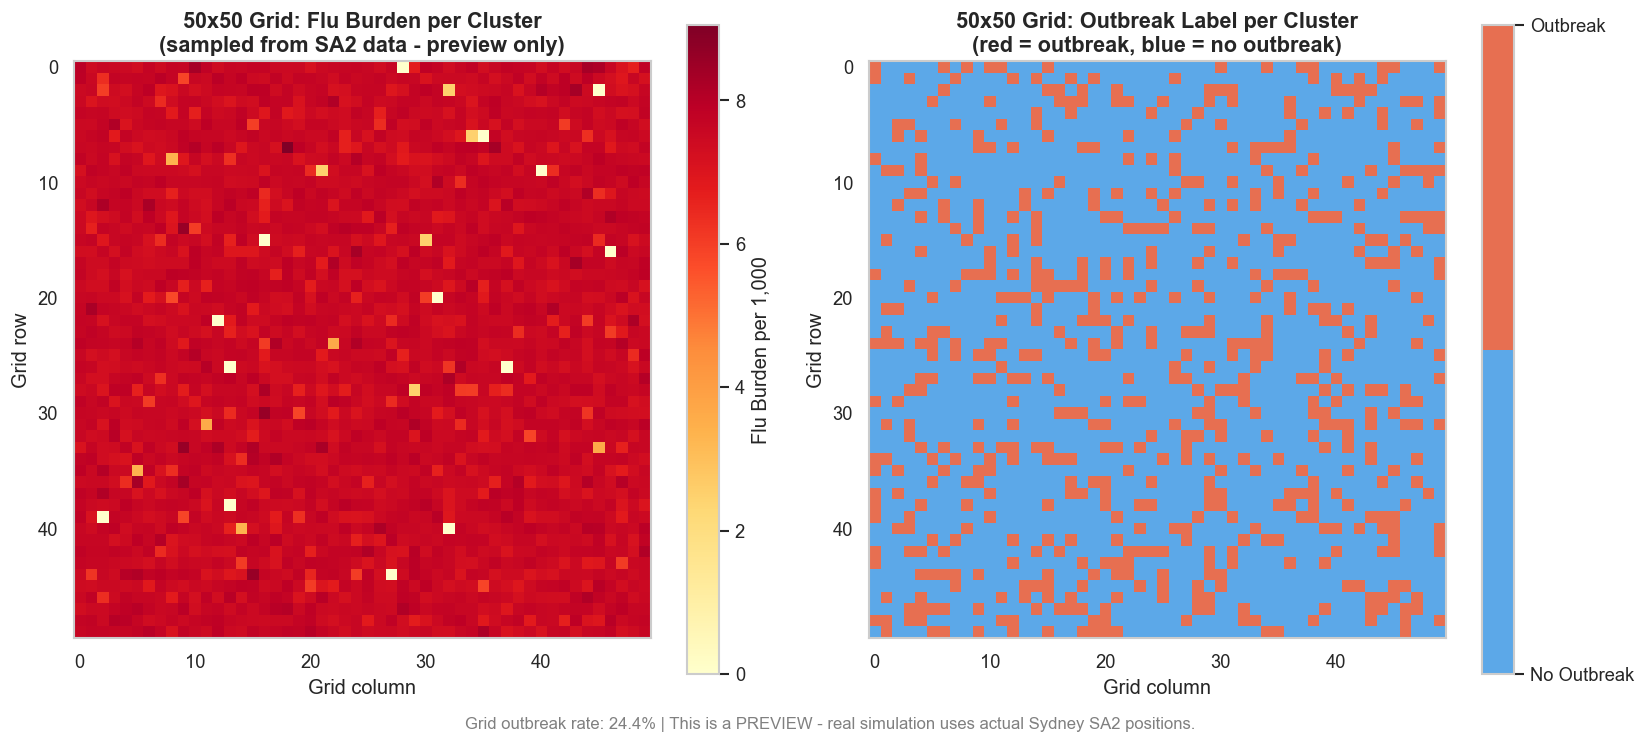

In [20]:
GRID_SIZE = 50
np.random.seed(42)
burden_values = df['flu_burden_per_1000'].dropna().values
grid_burden = np.random.choice(burden_values, size=(GRID_SIZE, GRID_SIZE))
grid_outbreak = (grid_burden > df[df['outbreak']==1]['flu_burden_per_1000'].min()).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
ax = axes[0]
im = ax.imshow(grid_burden, cmap='YlOrRd', interpolation='nearest')
plt.colorbar(im, ax=ax, label='Flu Burden per 1,000')
ax.set_title('50x50 Grid: Flu Burden per Cluster\n(sampled from SA2 data - preview only)', fontweight='bold')
ax.set_xlabel('Grid column')
ax.set_ylabel('Grid row')
ax.grid(False)

ax = axes[1]
cmap_outbreak = mcolors.ListedColormap(['#5ca8e8', '#e76f51'])
im2 = ax.imshow(grid_outbreak, cmap=cmap_outbreak, interpolation='nearest', vmin=0, vmax=1)
cbar2 = plt.colorbar(im2, ax=ax, ticks=[0, 1])
cbar2.set_ticklabels(['No Outbreak', 'Outbreak'])
ax.set_title('50x50 Grid: Outbreak Label per Cluster\n(red = outbreak, blue = no outbreak)', fontweight='bold')
ax.set_xlabel('Grid column')
ax.set_ylabel('Grid row')
ax.grid(False)

pct_outbreak = grid_outbreak.mean() * 100
plt.figtext(0.5, -0.02,
            f'Grid outbreak rate: {pct_outbreak:.1f}% | '
            f'This is a PREVIEW - real simulation uses actual Sydney SA2 positions.',
            ha='center', fontsize=10, color='grey')
plt.tight_layout()
plt.show()

The burden heatmap shows the spatial heterogeneity that arises when real SA2 flu burden values are distributed across the grid — hot spots (yellow-red) and cold spots (pale yellow) emerge naturally from the data. The binary outbreak grid illustrates how the threshold-based classification partitions the landscape into vulnerable and non-vulnerable clusters. Note that this is a randomised preview only; the actual simulation will use geographically accurate SA2 positions rather than random sampling.

### SIR Spread Preview

The following simulation seeds infection at three grid locations and runs a simplified SIR model for 20 time steps. The transmission rate (beta) at each cell is scaled by that cell's flu burden, so high-burden clusters amplify local spread while low-burden clusters act as natural barriers.

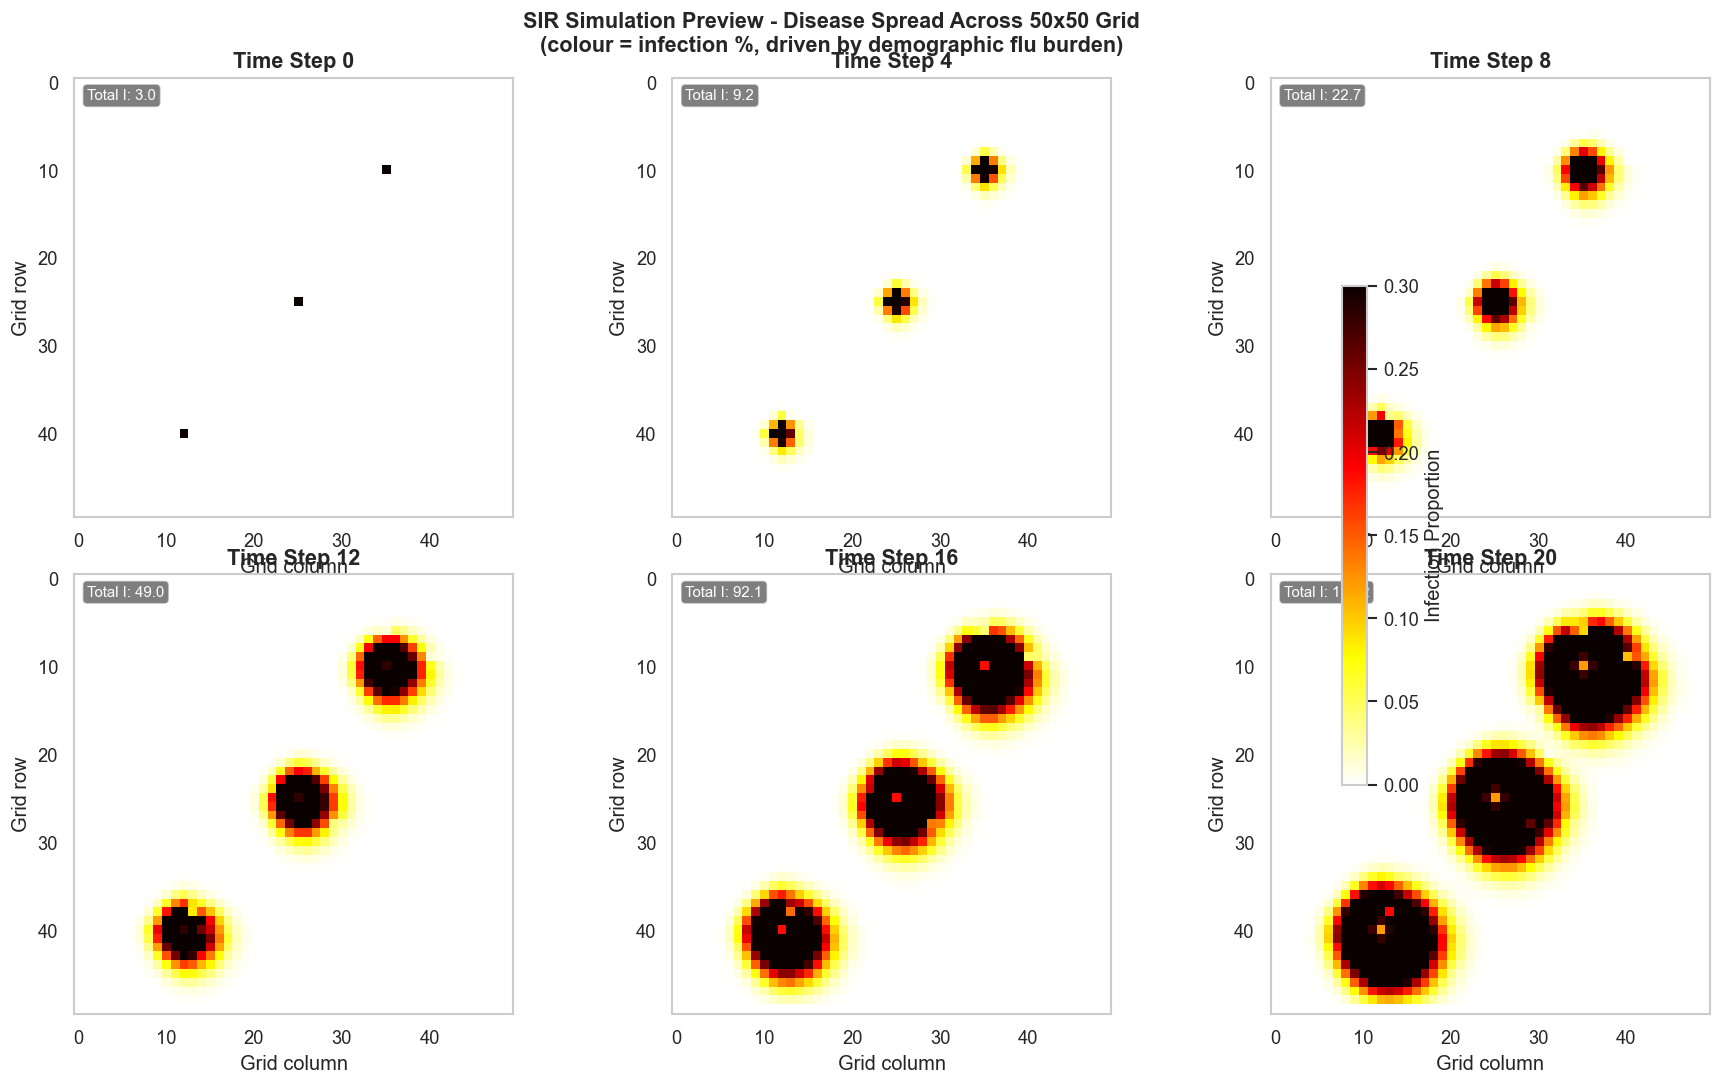


This is a simplified preview. The real SIR model will use:
  - ML-predicted spreadability scores per SA2 (not random)
  - Actual Sydney suburb geography (not a square grid)
  - Commuter-weighted inter-cluster spread
  - Policy levers: vaccination sliders, mobility restrictions


In [21]:
np.random.seed(7)
S = np.ones((GRID_SIZE, GRID_SIZE))
I = np.zeros((GRID_SIZE, GRID_SIZE))
R = np.zeros((GRID_SIZE, GRID_SIZE))
for r, c in [(25, 25), (10, 35), (40, 12)]:
    I[r, c] = 1.0
    S[r, c] = 0.0
beta_grid = (grid_burden - grid_burden.min()) / (grid_burden.max() - grid_burden.min()) * 0.4 + 0.1
gamma = 0.1
snapshots = [I.copy()]
for _ in range(20):
    for i in range(1, GRID_SIZE-1):
        for j in range(1, GRID_SIZE-1):
            neighbour_I = (I[i-1,j] + I[i+1,j] + I[i,j-1] + I[i,j+1]) / 4
            new_infected = beta_grid[i,j] * S[i,j] * neighbour_I
            new_recovered = gamma * I[i,j]
            S[i,j] = max(0, S[i,j] - new_infected)
            I[i,j] = max(0, I[i,j] + new_infected - new_recovered)
            R[i,j] = min(1, R[i,j] + new_recovered)
    snapshots.append(I.copy())

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, step in zip(axes.flatten(), [0, 4, 8, 12, 16, 20]):
    im = ax.imshow(snapshots[step], cmap='hot_r', vmin=0, vmax=0.3, interpolation='nearest')
    ax.set_title(f'Time Step {step}', fontweight='bold')
    ax.set_xlabel('Grid column')
    ax.set_ylabel('Grid row')
    ax.grid(False)
    total_infected = snapshots[step].sum()
    ax.text(1, 2, f'Total I: {total_infected:.1f}', color='white', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='black', alpha=0.5))
plt.colorbar(im, ax=axes.flatten(), label='Infection Proportion', shrink=0.6)
plt.suptitle('SIR Simulation Preview - Disease Spread Across 50x50 Grid\n'
             '(colour = infection %, driven by demographic flu burden)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('\nThis is a simplified preview. The real SIR model will use:')
print('  - ML-predicted spreadability scores per SA2 (not random)')
print('  - Actual Sydney suburb geography (not a square grid)')
print('  - Commuter-weighted inter-cluster spread')
print('  - Policy levers: vaccination sliders, mobility restrictions')

The six-panel time evolution shows how infection radiates outward from the three seed points, with the speed and intensity of spread modulated by the local flu burden. High-burden grid cells (corresponding to elderly-heavy suburbs) amplify transmission, while low-burden cells slow it down, creating irregular wavefronts rather than uniform circular expansion. The real simulation will improve upon this preview by incorporating actual Sydney SA2 geographic positions instead of a regular grid, ML-predicted spreadability scores rather than randomly sampled values, commuter-weighted inter-cluster connectivity to model cross-suburb transmission, and adjustable policy levers such as vaccination coverage and mobility restrictions.

---
## 10. Summary

This visualisation report has established several key findings that will guide the subsequent modelling and simulation stages:

- **Age is the dominant risk factor:** The proportion of residents aged 65+ is the single strongest predictor of flu outbreak vulnerability, with the oldest SA2 suburbs showing flu burden rates several times higher than the youngest.
- **Income provides complementary signal:** Lower-income suburbs cluster with outbreak labels, reflecting compounding disadvantages in healthcare access and vaccination uptake.
- **Seasonality is sharply defined:** NSW influenza activity concentrates in June-September, with COVID-19 measures causing an unprecedented two-year suppression followed by a strong 2022 rebound.
- **Flu burden separates classes cleanly:** The derived flu_burden_per_1000 metric shows near-complete separation between outbreak and non-outbreak suburbs in violin plots, validating its use as both a feature and a labelling criterion.
- **Feature correlations reveal multicollinearity:** Median age, pct_65plus, and flu burden are highly correlated, requiring careful feature selection or regularisation in the ML pipeline.
- **Grid simulation demonstrates heterogeneous spread:** Even in this simplified preview, demographic variation creates realistic irregular wavefronts, supporting the value of a spatially explicit SIR model.

The next notebooks will apply these insights to train outbreak classification models (Random Forest, Gradient Boosting) and build the interactive SIR simulation with policy-lever controls.